# Deduplicate and Visualize DEL Selections

This notebook accompanies code released for the [DREAM × CACHE Target 2035 Drug Discovery Challenge](https://www.synapse.org/Synapse:syn75349604/wiki/641044).

Baylor College of Medicine (BCM) DEL libraries sometimes use multiple DNA barcodes to encode the same chemical building block, or use multiple protecting groups on the same scaffold. As a result, some DEL molecules are split into multiple entries in the raw selection data. This notebook deduplicates the dataset by aggregating counts and zscores for entries that share the same SMILES string.

All processing uses `del_deduplicate.py`, a standalone script included alongside this notebook.

---

## Setup

Install dependencies with conda (Python 3.11 recommended):

```bash
conda env create -f environment.yaml
conda activate del-dedup
```

| Package      | Version (tested) |
| ------------ | ---------------- |
| `numpy`      | 2.3.3            |
| `pandas`     | 2.3.2            |
| `polars`     | 1.38.1           |
| `tqdm`       | 4.67.1           |
| `matplotlib` | 3.10.6           |
| `ipykernel`  | 6.31.0           |
| `pyarrow`    | 24.0.0           |

---

## `deduplicate_files` — parameters and options

```python
deduplicate_files(
    glob_pattern,          # path or glob to input parquet file(s)
    output_dir,            # directory for deduplicated output files
    suffix        = "_deduplicated",  # appended to output filenames
    dedup_col     = "SMILES",         # column to group by
    compound_col  = "compound",       # compound ID column for format validation (None = skip)
    smiles_col    = "SMILES",         # SMILES column for structural validation
    aggregation   = None,             # dict of {column: method} (see below)
    show_progress = True,             # display tqdm progress bar
)
```

### Aggregation methods

| Method       | Formula              | When to use                                      |
| ------------ | -------------------- | ------------------------------------------------ |
| `"sum"`      | Σ x                  | Count columns — preserves total observed reads   |
| `"stouffer"` | Σ z / √n             | Z-score columns — combines independent Z-scores  |
| `"max"`      | max(x)               | Flag columns — worst-case across duplicates      |
| `"mean"`     | Σ x / n              | Alternative to sum when normalising for copies   |
| `"median"`   | median(x)            | Robust alternative to mean                       |
| `"min"`      | min(x)               | Minimum value across duplicates                  |

If `aggregation=None`, methods are inferred automatically from column name suffixes:
columns ending in `_count` → `"sum"`, columns ending in `_zscore` or `_score` → `"stouffer"`.
All other columns retain the first observed value per group.

### Processing multiple files

`glob_pattern` accepts any glob expression, so you can process an entire directory at once:

```python
# Process all parquet files in a directory
deduplicate_files(
    glob_pattern = "selection_raw/*.parquet",
    output_dir   = "selection_deduplicated/",
)
```

### Deduplicating a DataFrame directly

Use `deduplicate_dataframe` if you already have data loaded in memory:

```python
from del_deduplicate import deduplicate_dataframe

df_dedup = deduplicate_dataframe(
    df,
    dedup_col   = "SMILES",
    aggregation = {"count_PGK2": "sum", "zscore_PGK2": "stouffer"},
)
```

---

## Aggregation considerations

There are multiple valid approaches to aggregating duplicate DEL entries. The scheme below is a reasonable default, but feel free to experiment:

| Column Type                                              | Recommended method            | Alternative                         |
| -------------------------------------------------------- | ----------------------------- | ----------------------------------- |
| **count columns** (e.g., `target_count`, `ntc_count`)    | **Sum** — total reads         | Mean — normalises for copy number   |
| **zscore columns** (e.g., `target_zscore`, `ntc_zscore`) | **Stouffer's Z** — `Σz / √n`  | Mean — simpler but ignores n        |
| **flag / indicator columns** (e.g., `historic_hits`)     | **Max** — worst-case          | Sum — total count across duplicates |


## Example: Deduplicate PGK2 selection data

Raw selection data is available on [Synapse](https://www.synapse.org/Synapse:syn75349604/wiki/641044). Update the path below to point to your downloaded parquet file.


In [1]:
from del_deduplicate import deduplicate_files, print_dedup_summary

In [ ]:
pgk2_dedup = deduplicate_files(
    glob_pattern = '/path/to/DEL_selection.parquet',
    output_dir   = '.',
    max_workers  = 1,
    dedup_col    = 'SMILES',
    aggregation  = {
        'count_PGK2':                'sum',
        'count_PGK2_with_inhibitor': 'sum',
        'count_NTC':                 'sum',
        'zscore_PGK2':               'stouffer',
        'zscore_PGK2_with_inhibitor': 'stouffer',
        'zscore_NTC':                'stouffer',
        'historic_hits':             'max',
    },
)

Processing files: 100%|██████████| 1/1 [00:05<00:00,  5.38s/it]


In [3]:
print_dedup_summary(pgk2_dedup)


── Deduplication Summary ────────────────────────────────
  Files processed : 1
  Files failed    : 0

  PGK2_selection_raw
    Original rows  :    7,703,070
    After cleaning :    7,674,854  (-0.4%)
    After dedup    :    7,487,567  (-2.8%)
    Aggregated     : count_PGK2, count_PGK2_with_inhibitor, count_NTC, zscore_PGK2, zscore_PGK2_with_inhibitor, zscore_NTC, historic_hits
    Output         : PGK2_selection_raw_deduplicated.parquet
───────────────────────────────────────────────────────


## Visualise selection data

Load the deduplicated parquet and inspect the count and Z-score distributions.

In [1]:
import pandas as pd
from del_deduplicate import plot_selection_counts, plot_selection_enrichment, plot_cubic_library_space

In [ ]:
df = pd.read_parquet('DEL_selection_deduplicated.parquet')
df.head()

,compound,SMILES,count_PGK2,count_PGK2_with_inhibitor,count_NTC,zscore_PGK2,zscore_PGK2_with_inhibitor,zscore_NTC,historic_hits
0,qDOS18_3-129-202-532,CNC(=O)c1cc(-n2c(-c3cnc4ccccc4n3)nc3cc(CN[C@H]...,1,0,0,0.0066,0.0,0.0,0
1,qDOS18_3-106-7-40,CNC(=O)[C@H]1C[C@@H](n2c(C3(OC(C)C)CC3)nc3ccc(...,1,0,0,0.0054,0.0,0.0,0
2,qDOS11-35-915-218,CNC(=O)C[C@@H]1CN(S(=O)(=O)c2cc(C)c(OC)cc2C)C[...,1,0,0,0.0054,0.0,0.0,0
3,qDOS42_2-513-32-358,CNC(=O)CC1CCN(C(=O)c2nn(C)cc2Cc2c[nH]c3ccc(NC(...,1,0,0,0.0320,0.0,0.0,0
4,qDOS18_3-103-171-363,CCOCCNCc1cnc2c(c1)nc(CCc1ccncn1)n2[C@H]1CC[C@H...,1,0,0,0.0055,0.0,0.0,0


### Count distribution

Shows how many times each compound was sequenced across the selection. The vast majority of compounds are not observed in the selection experience (non-binders). Most of the observed compounds have a low count of one or two (noise floor), while genuine binders appear as a long tail of high-count outliers. 

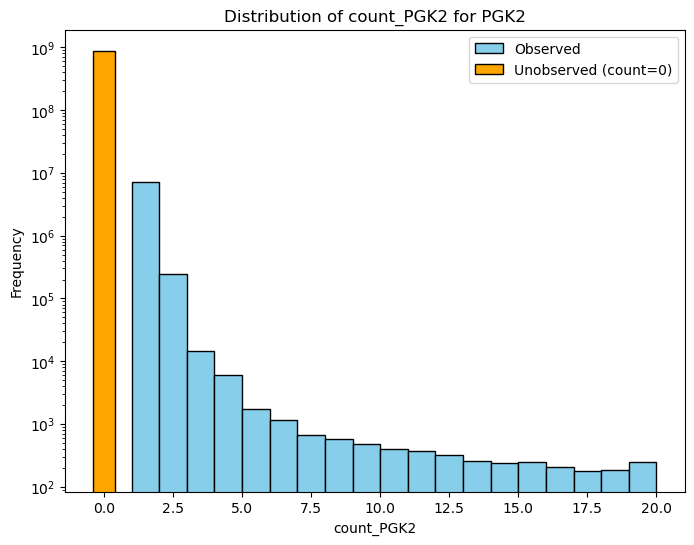

In [3]:
count_distribution = plot_selection_counts(
    target_name = "PGK2",
    target_data = df,
    total_compounds = 890_000_000,
    count_col = "count_PGK2",
    max_count = 20,
    min_count= 1,
    yscale = "log",
    ylim = None,
)

### Zscore (enrichment) distribution

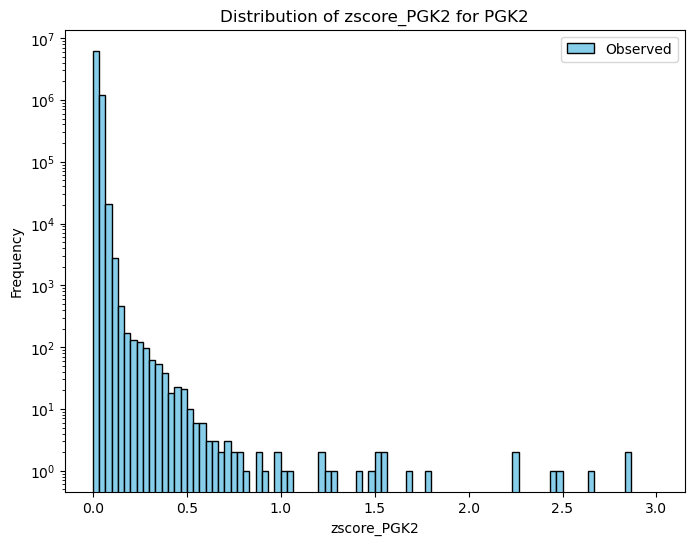

In [4]:
zscore_distribution = plot_selection_enrichment(
    target_name= "PGK2",
    target_data= df,
    enrichment_col= "zscore_PGK2",
    min_value= 0.0,
    max_value= 3.0,
    yscale = "log",
    ylim = None,
)

### Cube plot

Each axis represents one building-block position (BB1, BB2, BB3), placing every compound at a unique coordinate in combinatorial library space.

The spatial geometry of a cluster reveals which building blocks drive enrichment:

| Pattern         | What it means                                                                          |
| --------------- | -------------------------------------------------------------------------------------- |
| Isolated point  | A **trisynthon** hit — singleton hit without SAR support                               |
| Line of points  | A **disynthon** hit — hits share two building blocks in common (this demonstrates SAR) |
| Plane of points | A **monosynthon** hit — a single building block is driving enrichment                  |

<br>

> **NOTE :** Line features with a variation in counts/enrichment can be a good sign of SAR in DEL hits. However, line features with uniform counts/enrichment are often caused when the variable building block is outside of the binding pocket or a cycle of chemical synthesis has failed. 

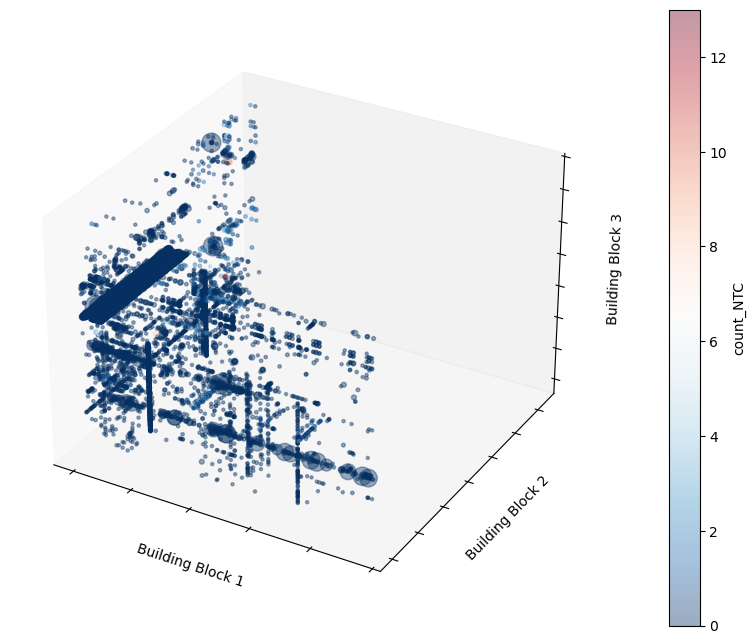

In [3]:
cube_plot = plot_cubic_library_space(
    df = df,
    compound_col = "compound",
    compound_delimiter = "-",
    size_col = "count_PGK2",
    size_min = 4.0,
    color_col = "count_NTC",
    max_marker_size = 250,
    min_marker_size = 5,
    cmap = "RdBu_r",
    title = None,
)

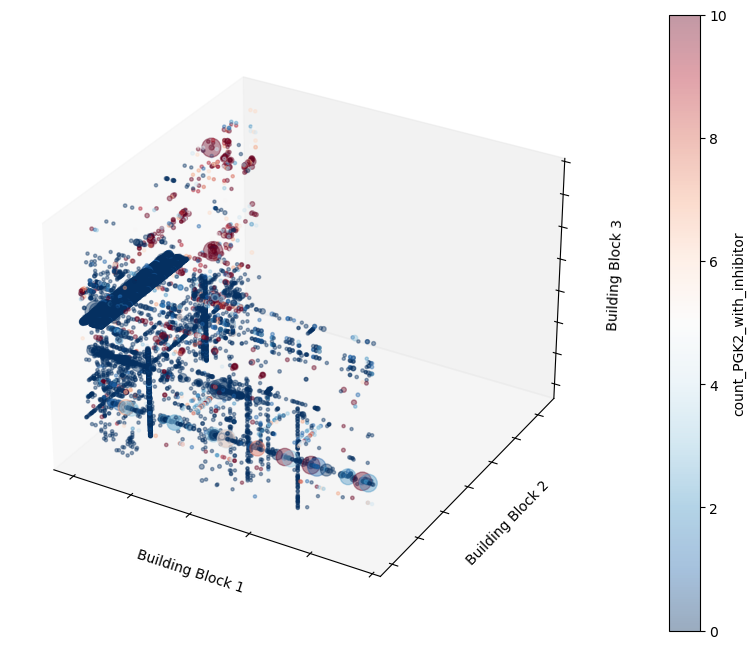

In [4]:
cube_plot = plot_cubic_library_space(
    df = df,
    compound_col = "compound",
    compound_delimiter = "-",
    size_col = "count_PGK2",
    size_min = 4.0,
    color_col = "count_PGK2_with_inhibitor",
    color_max = 10,
    max_marker_size = 250,
    min_marker_size = 5,
    cmap = "RdBu_r",
    title = None,
)